# Dependencies

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Set random seed

In [ ]:
import numpy as np
import random

# Set seed
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Ensures deterministic behavior

set_seed(42)  # You can change 42 to any preferred seed value


# Find device

In [ ]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# MNIST as Dataset

In [ ]:
from torch.utils.data import random_split

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training and test datasets
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# Define the sizes for training and validation sets
train_size = int(0.8 * len(train_dataset))  # 80% training
val_size = len(train_dataset) - train_size  # 20% validation

# Split the dataset
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}, Validation size: {len(val_dataset)}, Test size: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]

Train size: 48000, Validation size: 12000, Test size: 10000


# Defining the baseline model

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # Note: 4 hidden layers, 128 neurons each, overparameterized on purpose
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 10)  # Output layer for 10 classes

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the image
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)  # No activation (logits for cross-entropy loss)
        return x

In [ ]:
# Move model to GPU if available
baseline_model = MLP().to(device)
print(baseline_model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=10, bias=True)
)


# Training

## Adding L1 regularization

In [ ]:
def compute_l1_loss(model, lambda_l1=1e-5):
    l1_loss = 0.0
    for module in model.modules():
        if isinstance(module, nn.Linear):  # Apply L1 only to Linear layers
            l1_loss += torch.sum(torch.abs(module.weight))
    return lambda_l1 * l1_loss  # Scale the L1 loss using lambda


## Hyperparameters

In [ ]:
num_of_epochs = 20  # Number of epochs
lr = 0.001 # Learning rate

criterion = nn.CrossEntropyLoss() # Cross Entropy Loss
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=lr) # ADAM optimizer

## Training loop for baseline model

In [ ]:
import matplotlib.pyplot as plt

def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Add L1 regularization
            l1_loss = compute_l1_loss(model)
            loss += l1_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Compute training accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val

        # Store metrics for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies


In [ ]:
# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train(baseline_model, train_loader, val_loader, criterion, baseline_optimizer, device, epochs=num_of_epochs)

Epoch [1/20] - Train Loss: 0.3580, Train Acc: 90.34% | Val Loss: 0.1955, Val Acc: 93.78%
Epoch [2/20] - Train Loss: 0.1675, Train Acc: 96.29% | Val Loss: 0.1317, Val Acc: 95.95%
Epoch [3/20] - Train Loss: 0.1394, Train Acc: 97.15% | Val Loss: 0.1177, Val Acc: 96.56%
Epoch [4/20] - Train Loss: 0.1225, Train Acc: 97.66% | Val Loss: 0.1201, Val Acc: 96.55%
Epoch [5/20] - Train Loss: 0.1136, Train Acc: 98.04% | Val Loss: 0.1216, Val Acc: 96.52%
Epoch [6/20] - Train Loss: 0.1049, Train Acc: 98.30% | Val Loss: 0.1161, Val Acc: 96.80%
Epoch [7/20] - Train Loss: 0.1007, Train Acc: 98.42% | Val Loss: 0.1082, Val Acc: 97.24%
Epoch [8/20] - Train Loss: 0.0948, Train Acc: 98.62% | Val Loss: 0.1084, Val Acc: 97.30%
Epoch [9/20] - Train Loss: 0.0892, Train Acc: 98.81% | Val Loss: 0.1021, Val Acc: 97.36%
Epoch [10/20] - Train Loss: 0.0897, Train Acc: 98.88% | Val Loss: 0.1107, Val Acc: 97.04%
Epoch [11/20] - Train Loss: 0.0865, Train Acc: 98.98% | Val Loss: 0.1068, Val Acc: 97.35%
Epoch [12/20] - Tra

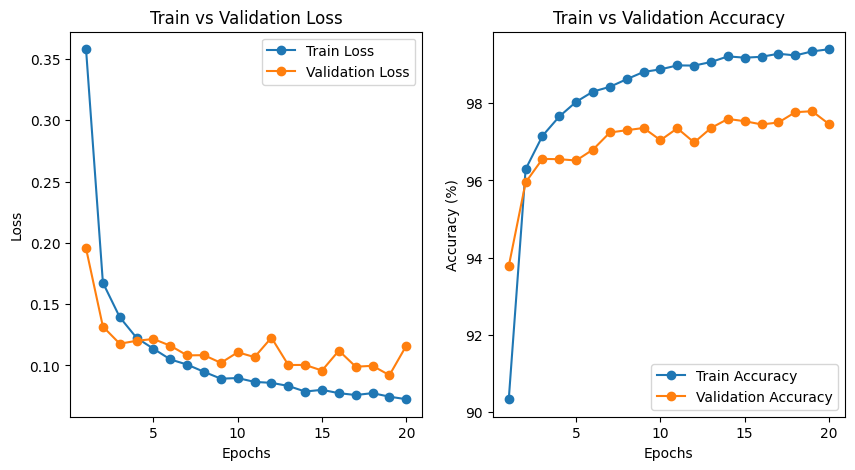

In [ ]:
# Plot the losses
plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.show()

# Evaluation

In [ ]:
def evaluate(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

## Training accuracy

In [ ]:
evaluate(baseline_model, train_loader, device)

Test Accuracy: 99.33%


## Test accuracy

In [ ]:
evaluate(baseline_model, test_loader, device)

Test Accuracy: 97.63%


# Pruning

## Unstructured

In [ ]:
# Define pruning
import torch.nn.utils.prune as prune

def two_stage_unstructured_prune(model, percentile=10):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):  # Apply pruning only on Linear layers
            weight = module.weight.data
            grad = module.weight.grad

            if grad is not None:
                # Compute gradient threshold (10th percentile within the same neuron)
                grad_threshold = torch.quantile(torch.abs(grad), percentile / 100)

                # Mask for weights with low gradients
                low_grad_mask = torch.abs(grad) < grad_threshold

                # Compute weight threshold from the entire weight matrix (not just low-grad ones)
                weight_threshold = torch.quantile(torch.abs(weight), percentile / 100)  # This is the change!

                # Prune weights that are both low-gradient and below the weight threshold
                prune_mask = (torch.abs(weight) < weight_threshold) & low_grad_mask
                weight[prune_mask] = 0  # Zero-out pruned weights


In [ ]:
# Calculate sparsity
def compute_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, nn.Linear):
            total_params += module.weight.numel()
            zero_params += torch.sum(module.weight == 0).item()

    sparsity = (zero_params / total_params) * 100
    print(f"Model Sparsity: {sparsity:.2f}%")

### Fixed number of epochs

In [ ]:
PERCENTILE = 90

# Train loop with regularization and pruning
def train_with_pruning_fixed_epochs(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, prune_interval=5):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            l1_loss = compute_l1_loss(model) # L1 regularization
            loss += l1_loss

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct_val / total_val

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        # Apply pruning every `prune_interval` epochs
        if (epoch + 1) % prune_interval == 0:
            two_stage_unstructured_prune(model, percentile=PERCENTILE)
            print("Pruning applied.")
            compute_sparsity(model)

    return train_losses, val_losses, train_accuracies, val_accuracies

#### 5 epoch interval

In [ ]:
# Create model
unstructured_fixed_epoch_5_model = MLP().to(device)

# Hyperparameters
num_of_epochs = 20
lr = 0.001

criterion = nn.CrossEntropyLoss()
unstructured_fixed_epoch_5_optimizer = optim.Adam(unstructured_fixed_epoch_5_model.parameters(), lr=lr)

In [ ]:
# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_with_pruning_fixed_epochs(
    unstructured_fixed_epoch_5_model, train_loader, val_loader, criterion, unstructured_fixed_epoch_5_optimizer, device, epochs=num_of_epochs, prune_interval=5
)

Epoch [1/20] - Train Loss: 0.3505, Train Acc: 90.28% | Val Loss: 0.1747, Val Acc: 94.46%
Epoch [2/20] - Train Loss: 0.1745, Train Acc: 95.94% | Val Loss: 0.1553, Val Acc: 95.29%
Epoch [3/20] - Train Loss: 0.1387, Train Acc: 97.17% | Val Loss: 0.1109, Val Acc: 96.77%
Epoch [4/20] - Train Loss: 0.1229, Train Acc: 97.60% | Val Loss: 0.1181, Val Acc: 96.71%
Epoch [5/20] - Train Loss: 0.1127, Train Acc: 97.95% | Val Loss: 0.1289, Val Acc: 96.17%
Pruning applied.
Model Sparsity: 81.30%
Epoch [6/20] - Train Loss: 0.1395, Train Acc: 96.79% | Val Loss: 0.0994, Val Acc: 97.09%
Epoch [7/20] - Train Loss: 0.0964, Train Acc: 98.18% | Val Loss: 0.1023, Val Acc: 97.05%
Epoch [8/20] - Train Loss: 0.0893, Train Acc: 98.41% | Val Loss: 0.0963, Val Acc: 97.38%
Epoch [9/20] - Train Loss: 0.0864, Train Acc: 98.59% | Val Loss: 0.1064, Val Acc: 97.18%
Epoch [10/20] - Train Loss: 0.0843, Train Acc: 98.69% | Val Loss: 0.1027, Val Acc: 97.09%
Pruning applied.
Model Sparsity: 81.62%
Epoch [11/20] - Train Loss: 0

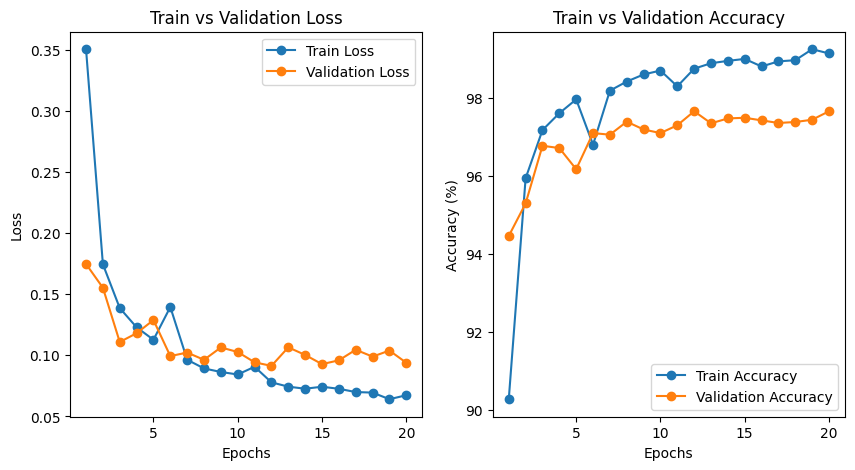

In [ ]:
# Plot the losses
plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
# Train accuracy
evaluate(unstructured_fixed_epoch_5_model, train_loader, device)

Test Accuracy: 99.54%


In [ ]:
# Test accuracy
evaluate(unstructured_fixed_epoch_5_model, test_loader, device)

Test Accuracy: 97.22%


#### 1 epoch interval

In [ ]:
# Create model
unstructured_fixed_epoch_1_model = MLP().to(device)

# Hyperparameters
num_of_epochs = 20
lr = 0.001

criterion = nn.CrossEntropyLoss()
unstructured_fixed_epoch_1_optimizer = optim.Adam(unstructured_fixed_epoch_1_model.parameters(), lr=lr)

In [ ]:
# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train_with_pruning_fixed_epochs(
    unstructured_fixed_epoch_1_model, train_loader, val_loader, criterion, unstructured_fixed_epoch_1_optimizer, device, epochs=num_of_epochs, prune_interval=1
)

Epoch [1/20] - Train Loss: 0.3534, Train Acc: 90.32% | Val Loss: 0.1722, Val Acc: 94.81%
Pruning applied.
Model Sparsity: 81.60%
Epoch [2/20] - Train Loss: 0.2034, Train Acc: 94.77% | Val Loss: 0.1420, Val Acc: 95.78%
Pruning applied.
Model Sparsity: 81.76%
Epoch [3/20] - Train Loss: 0.1503, Train Acc: 96.36% | Val Loss: 0.1172, Val Acc: 96.43%
Pruning applied.
Model Sparsity: 81.93%
Epoch [4/20] - Train Loss: 0.1287, Train Acc: 96.96% | Val Loss: 0.1147, Val Acc: 96.74%
Pruning applied.
Model Sparsity: 81.81%
Epoch [5/20] - Train Loss: 0.1157, Train Acc: 97.38% | Val Loss: 0.1191, Val Acc: 96.42%
Pruning applied.
Model Sparsity: 81.74%
Epoch [6/20] - Train Loss: 0.1078, Train Acc: 97.57% | Val Loss: 0.1039, Val Acc: 97.03%
Pruning applied.
Model Sparsity: 81.90%
Epoch [7/20] - Train Loss: 0.1029, Train Acc: 97.76% | Val Loss: 0.1020, Val Acc: 97.02%
Pruning applied.
Model Sparsity: 82.03%
Epoch [8/20] - Train Loss: 0.0997, Train Acc: 97.84% | Val Loss: 0.1012, Val Acc: 97.01%
Pruning 

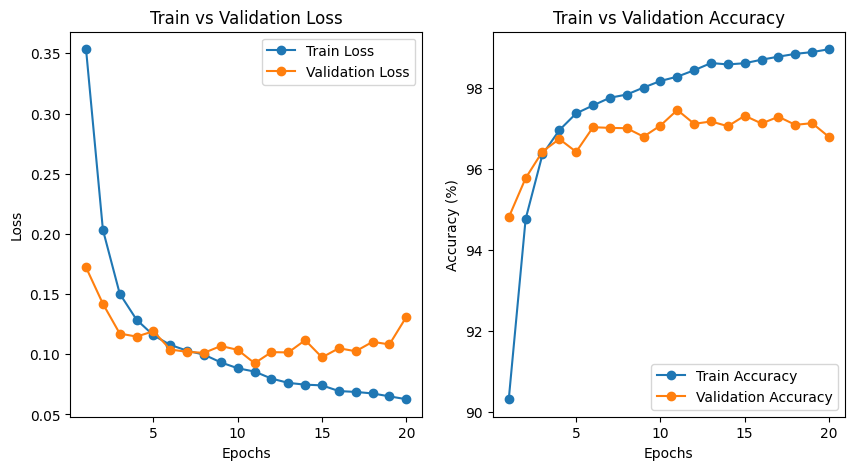

In [ ]:
# Plot the losses
plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
# Train accuracy
evaluate(unstructured_fixed_epoch_1_model, train_loader, device)

Test Accuracy: 99.36%


In [ ]:
# Test accuracy
evaluate(unstructured_fixed_epoch_1_model, test_loader, device)

Test Accuracy: 97.90%


# Creating overall graph

In [ ]:
sparsity = {
    "w/o reg, interval=5": {10: 1.10, 30: 8.13, 50: 25.66, 70: 49.60, 90: 81.51},
    "w/o reg, interval=1": {10: 1.30, 30: 9.37, 50: 26.98, 70: 50.24, 90: 81.76},
    "w/ reg, interval=5": {10: 0.59, 30: 5.93, 50: 20.15, 70: 52.91, 90: 82.11},
    "w/ reg, interval=1": {10: 1.07, 30: 5.45, 50: 20.90, 70: 52.97, 90: 82.23}
}

test_acc = {
    "w/o reg, interval=5": {10: 97.87, 30: 97.14, 50: 97.67, 70: 97.57, 90: 94.07},
    "w/o reg, interval=1": {10: 97.80, 30: 97.63, 50: 97.61, 70: 97.76, 90: 97.99},
    "w/ reg, interval=5": {10: 97.87, 30: 97.44, 50: 97.97, 70: 97.64, 90: 97.22},
    "w/ reg, interval=1": {10: 97.45, 30: 97.52, 50: 97.86, 70: 97.88, 90: 97.90}
}

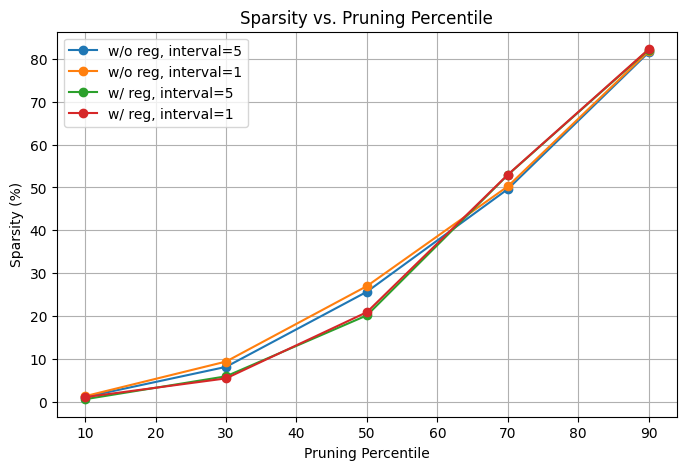

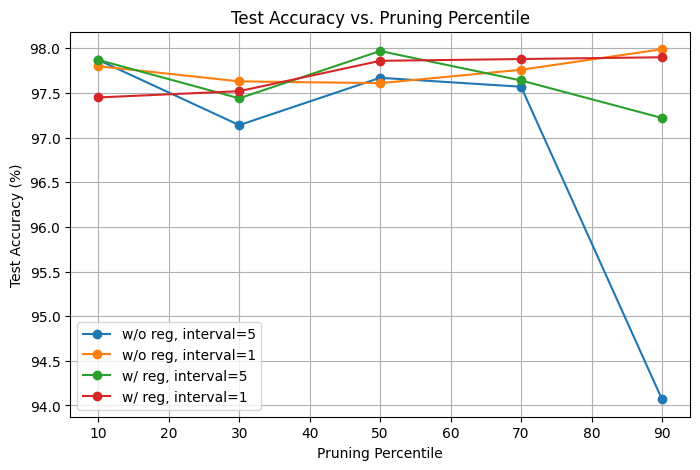

In [ ]:
import matplotlib.pyplot as plt

def plot_results(data, title, ylabel):
    plt.figure(figsize=(8, 5))

    for label, values in data.items():
        x = list(values.keys())  # Percentiles
        y = list(values.values())  # Corresponding values
        plt.plot(x, y, marker='o', label=label)  # Line plot with markers

    plt.xlabel("Pruning Percentile")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Sparsity
plot_results(sparsity, "Sparsity vs. Pruning Percentile", "Sparsity (%)")

# Plot Test Accuracy
plot_results(test_acc, "Test Accuracy vs. Pruning Percentile", "Test Accuracy (%)")